In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
PHYSICAL_PREDICTORS = ["Wd", "We"]   
TARGET = ["Theta", "X", "Y"]       
TIME_STEPS = 3

for i in range(4):
    Dataset = pd.read_excel(f"./../../RotedData/Data.xlsx", f"D{i+1}")   
    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]    
           
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"./../../Data/Data{i + 1}.csv")
        
    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]    
    
    Datasets.append(Dataset)
    

for i in range(len(Datasets)):
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head(5))

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
     X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE  DeltaTheta  DeltaX  \
0  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00         0.0     0.0   
1  0.0  0.7    0.0  0.00  0.0   3.02   3.02  -0.00   0.00         0.0     0.0   
2  0.0  0.7    0.0  0.00  0.0   3.02   3.02  45.32  45.32         0.0     0.0   
3  0.0  0.7    0.0  0.03  0.0   3.02   3.02  45.32  45.32         0.0     0.0   
4  0.0  0.7    0.0  0.00  0.0   3.02   3.02  63.00  63.44         0.0     0.0   

   DeltaY  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
     X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE  DeltaTheta  DeltaX  \
0  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00         0.0     0.0   
1  0.0  0.7    0.0  0.00  0.0   3.02   3.02  -0.00   0.00         0.0     0.0   
2  0.0  0.7    0.0  0.00  0.0   3.02   3.02  45.32  45.32         0.0     0.0   
3  0.0 

In [44]:
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]

    # Dropar apenas uma vez (mantém apenas linhas onde todos os deltas existem)
    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET])

    Datasets[i] = Dataset

    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].tail(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
     Unnamed: 0     X     Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE  \
971       67.97  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -52.65 -29.75   
972       68.04  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -47.56 -17.83   
973       68.11  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -47.56 -17.83   
974       68.18  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -42.47  -5.67   
975       68.25  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -42.47  -5.67   

     DeltaTheta  DeltaX  DeltaY  
971         0.0     0.0     0.0  
972         0.0     0.0     0.0  
973         0.0     0.0     0.0  
974         0.0     0.0     0.0  
975         0.0     0.0     0.0  
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
     Unnamed: 0     X     Y  Theta    Wd    We  WdRef  WeRef    PwmD    PwmE  \
971       67.97  0.04  0.66  -0.78 -2.40 -1.81  -3.20  -3.17 -112.80 -122.28   
972       68.04  0.04  0.67  -0.79 -2.93 -2.43  -3.27  -3.29 -112.80 

In [45]:
NormDatasets = []
TARGET = ["DeltaTheta", "DeltaX", "DeltaY"]

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

# ===== TRAIN FASE 1 =====
Train1 = Datasets[0].copy()
Train1[PREDICTORS] = SCALER.fit_transform(Train1[PREDICTORS])
Train1[TARGET] = OUT_SCALER.fit_transform(Train1[TARGET])
NormDatasets.append(Train1)

# ===== TRAIN FASE 2 =====
Train2 = Datasets[1].copy()
Train2[PREDICTORS] = SCALER.transform(Train2[PREDICTORS])
Train2[TARGET] = OUT_SCALER.transform(Train2[TARGET])
NormDatasets.append(Train2)


for i in range(4):
      CurrentTestDataset = Datasets[i + 2]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+2} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
   Unnamed: 0    X    Y  Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  \
0        0.00  0.0  0.7   0.00  0.00  0.0   0.00   0.00  0.221564  0.111917   
1        0.07  0.0  0.7   0.00  0.00  0.0   3.28   3.28  0.221564  0.111917   
2        0.14  0.0  0.7   0.00  0.00  0.0   3.28   3.28  0.803114  0.594038   
3        0.21  0.0  0.7   0.00  0.06  0.0   3.28   3.28  0.803114  0.594038   
4        0.28  0.0  0.7   0.01  0.33  0.0   3.28   3.28  1.025343  0.786494   

   DeltaTheta    DeltaX   DeltaY  
0    0.045457 -0.001615  0.00264  
1    0.045457 -0.001615  0.00264  
2    0.045457 -0.001615  0.00264  
3    0.600031 -0.001615  0.00264  
4    0.045457 -0.001615  0.00264  
++++++++++++++++++++ Dataset Normalizado 3 +++++++++++++++++++++++
   Unnamed: 0     X     Y  Theta   Wd   We  WdRef  WeRef      PwmD      PwmE  \
0        0.00  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -0.219706  0.175547   
1        0.07  0.01  

In [46]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

In [47]:
x_train1, y_train1 = CreateSequences(Train1[PREDICTORS], Train1[TARGET], TIME_STEPS)

x_train2, y_train2 = CreateSequences(Train2[PREDICTORS], Train2[TARGET], TIME_STEPS)

x_val, y_val = CreateSequences((NormDatasets[5])[PREDICTORS], (NormDatasets[5])[TARGET], TIME_STEPS)

print(f"Dimensão da entrada: {np.shape(x_train1)}")
print(f"Dimensão da saida: {np.shape(y_train1)}")

print(f"Dimensão da entrada: {np.shape(x_train2)}")
print(f"Dimensão da saida: {np.shape(y_train2)}")

print(f"Dimensão da entrada: {np.shape(x_val)}")
print(f"Dimensão da saida: {np.shape(x_val)}")

Dimensão da entrada: (973, 3, 2)
Dimensão da saida: (973, 3)
Dimensão da entrada: (973, 3, 2)
Dimensão da saida: (973, 3)
Dimensão da entrada: (1268, 3, 2)
Dimensão da saida: (1268, 3, 2)


In [51]:
x_train = np.concatenate((x_train1, x_train2), axis=0)
y_train = np.concatenate((y_train1, y_train2), axis=0)

Wd_train =  np.concatenate((Train1["Wd"].values[:len(x_train1)],
                            Train2["Wd"].values[:len(x_train2)]),
                           axis=0) 
We_train =  np.concatenate((Train2["Wd"].values[:len(x_train1)],
                            Train2["We"].values[:len(x_train2)]),
                           axis=0) 

In [52]:
print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

print(f"Dimensão da entrada fisica : {np.shape(Wd_train)}")
print(f"Dimensão da entrada fisica: {np.shape(We_train)}")

Dimensão da entrada: (1946, 3, 2)
Dimensão da saida: (1946, 3)
Dimensão da entrada fisica : (1946,)
Dimensão da entrada fisica: (1946,)


In [92]:
import matplotlib.pyplot as plt
import numpy as np

def PlotOut(ax, title, target_name, y_true, y_cin, y_pred):

    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.scatter(time, y_true,
               marker='o',
               s=12,
               color='tab:blue',
               label='Amostras Reais',
               alpha=0.7)

    ax.scatter(time, y_pred,
               marker='x',
               s=12,
               color='tab:red',
               label='Modelo PIRNN',
               alpha=0.7)

    ax.plot(time, y_cin,
            linewidth=2,
            color='tab:green',
            label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)

    ax.legend()
    ax.grid(True)

In [ ]:
import tensorflow as tf

R = 0.034
L = 0.147/2
dt = 0.07

def NumericalIntegration(Dataset, dq):
    
    init_vals = np.array([
        Dataset["Theta"].iloc[0],
        Dataset["X"].iloc[0],
        Dataset["Y"].iloc[0]
    ]) 
    
    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    x_cin     = init_vals[1] + np.cumsum(dq[1] * dt)
    y_cin     = init_vals[2] + np.cumsum(dq[2] * dt)
    return [theta_cin, x_cin, y_cin]


In [66]:
def CinematicModel(Wd, We, theta0):
    dtheta_cin = (R/(2*L)) * (Wd - We)
    theta_cin =  theta0 + np.cumsum(dtheta_cin * dt)
    dx_cin = (R/2) * np.cos(theta_cin) * (Wd + We)
    dy_cin = (R/2) * np.sin(theta_cin) * (Wd + We)
    return [dtheta_cin, dx_cin, dy_cin]

dq1 = CinematicModel(Train1["Wd"].values, Train1["We"].values, Train1["Theta"].values[0])
dq2 = CinematicModel(Train2["Wd"].values, Train2["We"].values, Train2["Theta"].values[0])

q1 = NumericalIntegration(Train1, dq1)
q2 = NumericalIntegration(Train2, dq2)

In [67]:
def cinematic_equations(theta, Wd, We):

    dtheta = (R/(2*L)) * (Wd - We)

    dx = (R/2) * (Wd + We) * tf.cos(theta)

    dy = (R/2) * (Wd + We) * tf.sin(theta)

    return tf.stack([dtheta, dx, dy], axis=1)

class PINN(tf.keras.Model):

    def __init__(self):
        super(PINN, self).__init__()

        self.rnn = tf.keras.layers.SimpleRNN(32)

        self.hidden = tf.keras.layers.Dense(16, activation='tanh')

        self.out_layer = tf.keras.layers.Dense(3)  # theta, x, y

    def call(self, inputs):

        x = self.rnn(inputs)

        x = self.hidden(x)

        return self.out_layer(x)

In [55]:
model = PINN()

optimizer = tf.keras.optimizers.Adam(0.001)

In [56]:
@tf.function
def train_step(x, y, Wd, We):

    with tf.GradientTape() as tape:

        pred = model(x, training=True)

        # loss dos dados
        data_loss = tf.reduce_mean(tf.square(pred - y))

        # derivada temporal da predição
        d_pred = (pred - y) / dt

        # termo físico
        physics = cinematic_equations(pred[:,0], Wd, We)

        physics_loss = tf.reduce_mean(tf.square(d_pred - physics))

        loss = data_loss + physics_loss

    gradients = tape.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [ ]:
Wd_train = tf.convert_to_tensor(Wd_train, dtype=tf.float32)
We_train = tf.convert_to_tensor(We_train, dtype=tf.float32)

x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

for epoch in range(20000):

    loss = train_step(x_train_tf, y_train_tf, Wd_train, We_train)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} Loss {loss.numpy():.6f}")

Epoch 0 Loss 111.594368
Epoch 50 Loss 111.450005
Epoch 100 Loss 111.294090
Epoch 150 Loss 111.465546
Epoch 200 Loss 110.995773
Epoch 250 Loss 110.845497
Epoch 300 Loss 110.734268
Epoch 350 Loss 110.552544
Epoch 400 Loss 110.404854
Epoch 450 Loss 110.595940
Epoch 500 Loss 110.113152
Epoch 550 Loss 109.978760
Epoch 600 Loss 109.828972
Epoch 650 Loss 109.700676
Epoch 700 Loss 109.547607
Epoch 750 Loss 109.585838
Epoch 800 Loss 109.275223
Epoch 850 Loss 109.140213
Epoch 900 Loss 109.012360
Epoch 950 Loss 108.879944
Epoch 1000 Loss 108.750038
Epoch 1050 Loss 108.918602
Epoch 1100 Loss 108.494522
Epoch 1150 Loss 108.593620
Epoch 1200 Loss 108.245842
Epoch 1250 Loss 108.200470
Epoch 1300 Loss 108.002266
Epoch 1350 Loss 107.910423
Epoch 1400 Loss 107.764091
Epoch 1450 Loss 107.660233
Epoch 1500 Loss 107.741562
Epoch 1550 Loss 107.417618
Epoch 1600 Loss 107.306900
Epoch 1650 Loss 107.192589
Epoch 1700 Loss 107.329765
Epoch 1750 Loss 106.971962
Epoch 1800 Loss 106.864044
Epoch 1850 Loss 106.8014

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def EvaluateModel(model, x_data, dataset, q_cin, title):

    # Predição da rede
    pred = model(tf.convert_to_tensor(x_data, dtype=tf.float32)).numpy()

    # Desnormalizar
    dq_pred = OUT_SCALER.inverse_transform(pred)

    # Formato para integração
    dq_pred = dq_pred.T

    # Integração numérica
    q_pred = NumericalIntegration(dataset, dq_pred)

    # Ajustar tamanho (por causa do TIME_STEPS)
    n = len(q_pred[0])

    theta_real = dataset["Theta"].values[:n]
    x_real     = dataset["X"].values[:n]
    y_real     = dataset["Y"].values[:n]

    theta_cin = q_cin[0][:n]
    x_cin     = q_cin[1][:n]
    y_cin     = q_cin[2][:n]

    # -------- métricas --------

    metrics = {}

    for name, real, pred_val in zip(
        ["Theta", "X", "Y"],
        [theta_real, x_real, y_real],
        [q_pred[0], q_pred[1], q_pred[2]]
    ):

        mse = mean_squared_error(real, pred_val)
        rmse = np.sqrt(mse)
        r2 = r2_score(real, pred_val)

        metrics[name] = {
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }

    # -------- plots --------

    fig, ax = plt.subplots(3,1, figsize=(8,12))

    PlotOut(ax[0], title, "Theta", theta_real, theta_cin, q_pred[0])
    PlotOut(ax[1], title, "X",     x_real,     x_cin,     q_pred[1])
    PlotOut(ax[2], title, "Y",     y_real,     y_cin,     q_pred[2])

    plt.tight_layout()
    plt.show()
    print(metrics)
    
    return metrics, q_pred

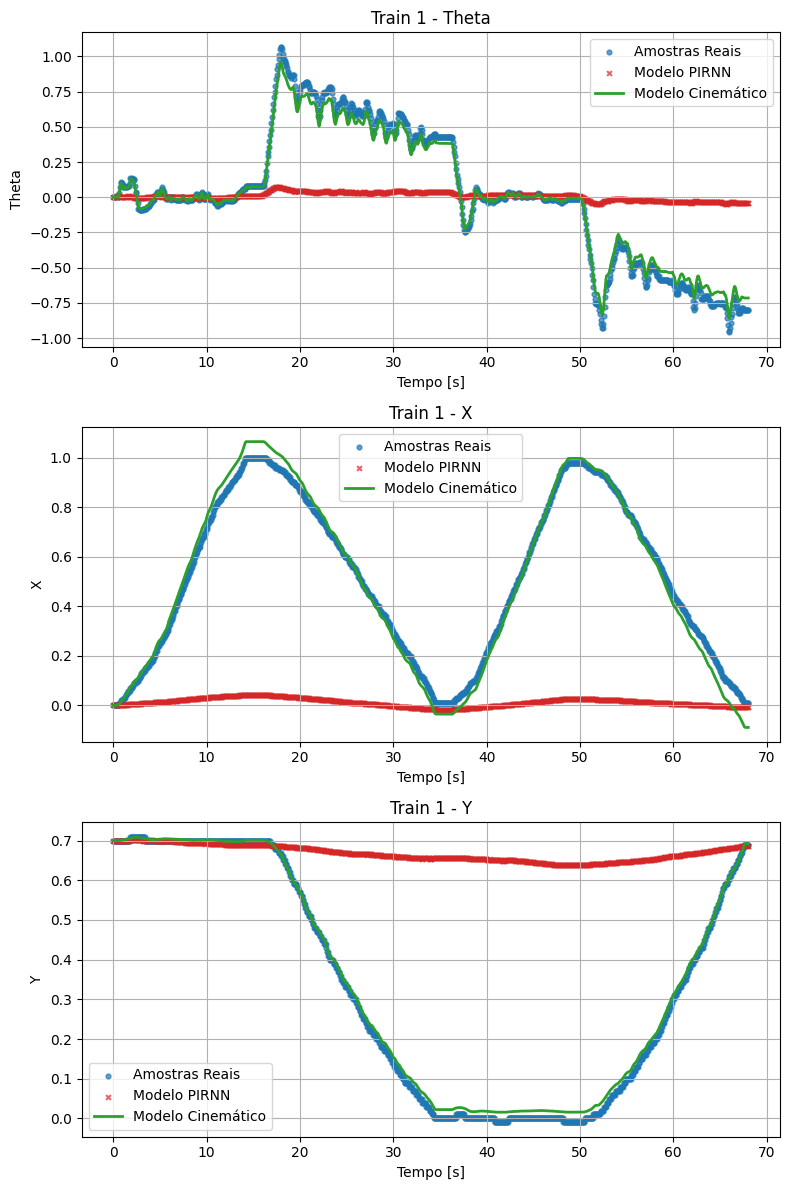

{'Theta': {'MSE': 0.20126385518310141, 'RMSE': 0.44862440324073033, 'R2': 0.10758885087139702}, 'X': {'MSE': 0.34953082742002756, 'RMSE': 0.5912113221345034, 'R2': -2.2403720258587576}, 'Y': {'MSE': 0.18632389014139203, 'RMSE': 0.4316525108711775, 'R2': -1.2227503053164654}}


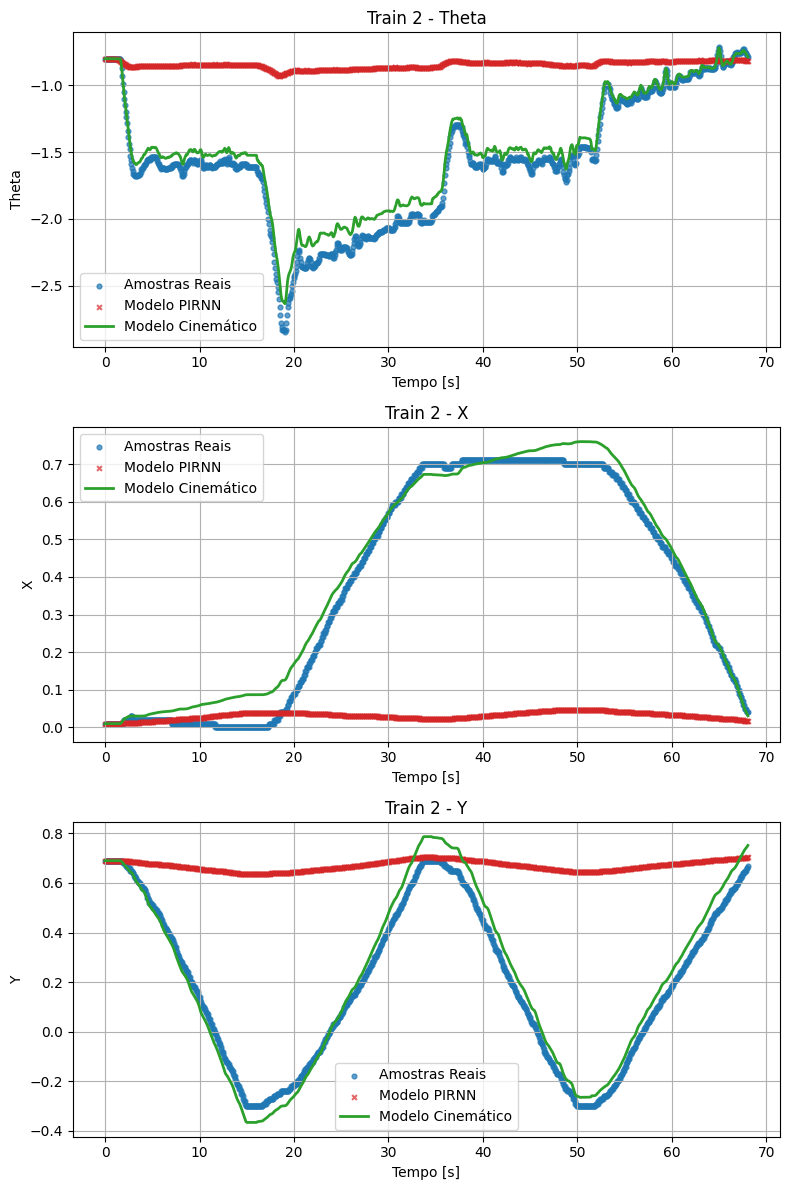

{'Theta': {'MSE': 0.7389731028107736, 'RMSE': 0.8596354476234525, 'R2': -2.237716879972441}, 'X': {'MSE': 0.2017349184844824, 'RMSE': 0.4491491049578997, 'R2': -1.3929295154993788}, 'Y': {'MSE': 0.3285246647808086, 'RMSE': 0.5731707117262784, 'R2': -2.0498345318258613}}


In [96]:
metrics1, q1_pred = EvaluateModel(
    model,
    x_train1,
    Train1,
    q1,
    "Train 1"
)

metrics2, q2_pred = EvaluateModel(
    model,
    x_train2,
    Train2,
    q2,
    "Train 2"
)